# Lakeside E+ — GL14 vs peak‑285 (W2A dial tutorial)

**Agent tutorial** for dialing a **W2A plant** twin: hold **utility monthly GL14**, shape **Jan‑26 peak** toward billed ~285 kW, keep overnight from exploding. Mirrors `skills/lakeside-w2a-plant-dial/SKILL.md` and `vibe22_agent_spec/W2A_PLANT_DIAL.md`.

| Model | Intent | Knobs (live expanded IDF) |
| --- | --- | --- |
| **C02** | Monthly GL14-only | cap×0.45, setback ~58 °F |
| **PK285** | Peak ≈ 285 kW (bills break) | cap×0.86, COP×0.79 |
| **L22 prior** | First dual | cap×1.45, COP×1.24, sb~46 °F, opt-start 3.5 h |
| **E20 enhanced (champion)** | Best dual after 20-trial dial | cap×1.70, COP×1.20, equip×0.75, lights×1.10, opt 3.5 h |

Monthly GL14 = **utility bill kWh**. Load shapes = **BAS** intervals. End-use stacks = schedule-scaled monthly meters (lights/plugs) + HVAC residual.

Set `LAKESIDE_SITE_ROOT` if needed (default Desktop `sp_creekside`).

## How an agent dials this model (correct areas)

This is the playbook that produced **E20**. Dial **post-ExpandObjects W2A** fields only (`eplus_native/w2a_plant_knobs.py`). Do **not** treat IdealLoads `*_best_utility.idf` as the same twin.

### 1. Lock the right gates

| Gate | Series | Pass |
| --- | --- | --- |
| Monthly GL14 (hard) | `reports/eplus/observed_monthly_utility.csv` | \|NMBE\| &lt; 5% **and** CVRMSE &lt; 15% |
| Design-day peak | BAS 15‑min on **2026-01-26** | Aim ~285 kW (utility billed demand 284.82 kW) |
| Overnight | Same day, hours 0–4 local | Prefer ≤ ~140 kW (Jan‑26 night is *not* winter mean ~68 kW) |

Monthly GL14 pass ≠ interval-shape / DSM GO — see `vibe22_agent_spec/EPLUS_MULTIRES.md`.

### 2. Dial in the correct object areas

| Knob | Where it mutates | Pull this way when… |
| --- | --- | --- |
| `htg_coil_capacity_mult` | Coil rated heating capacity | Peak short — need taller morning recovery |
| `htg_coil_cop_mult` | Coil COP → electric intensity | Bills high / peak electric too tall — raise COP; peak short & bills OK — slight COP cut |
| `setback_heat_sp_c` | Unocc heat SP in `SCH_HtgSP` | Overnight too high — deepen toward ~7.78 °C (~46 °F) |
| `optimum_start_h` | Morning Until times earlier | Need more pre-occ run hours (keep ≥ 3.5 h on dual hunt) |
| `equip_w_area_mult` | ElectricEquipment W/area (skip FanProxy) | Peak ≈285 but **GL14 fails** — **cut plugs** to 0.70–0.90 first |
| `lights_w_area_mult` | Lights W/area | Small daytime bump (1.05–1.20); large bumps break monthly |

**Banned:** `fan_avail_use_sch_hvac=True` (collapses load). Dead IdealLoads / pre-expand capacity knobs (refused — no plant effect).

### 3. Proven recipe order

1. Start from **cold setback + opt-start + high capacity + high-ish COP** (L22 family).
2. If peak still short of 275–285 → nudge capacity up / COP slightly down; **rescore GL14 every trial**.
3. If plugs/lights alone hit ~285 → expect monthly fail (E01–E10: NMBE −13%…−24%). Do not promote.
4. If peak ∈ 275–295 and GL14 fails → **cut `equip_w_area_mult`** (E16–E20 → **E20**). Optional qualitative check: `reports/zone_avg_fan_run_hours_monthly.csv`.
5. **Champion rule:** highest Jan‑26 peak among (GL14 pass ∧ overnight OK). Promote only if ≥5 kW better than prior dual.

### 4. CLI the agent should run

```powershell
$env:LAKESIDE_SITE_ROOT="…\sp_creekside"
python -u scripts/eplus_w2a_l22_enhanced_dial.py --max-trials 20
python -u scripts/eplus_l22_enduse_profile_plots.py
```

Needs expanded base: `eplus/campaigns/w2a_integrity_closure_*/shared/expand/expanded.idf`.

### 5. Scoreboard (what “success” looked like)

| Step | Result |
| --- | --- |
| C02 | GL14 easy, peak stuck ~191 kW |
| PK285 | Peak ~287 kW, monthly destroyed |
| L22 | Dual ~261 kW / GL14 pass |
| Plugs↑ alone | Peak 275–294 kW, GL14 fail |
| Equip cut + fat plant | **E20 ~271 kW / GL14 pass** (current champion) |
| Phase C toward 285 | E23 ~283 kW but GL14/overnight fail — kept E20 |

Full skill: `skills/lakeside-w2a-plant-dial/SKILL.md` · Spec: `vibe22_agent_spec/W2A_PLANT_DIAL.md`.

In [1]:
%matplotlib inline
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT / "ml"))
sys.path.insert(0, str(ROOT / "scripts"))
sys.path.insert(0, str(ROOT))

from lakeside.paths import site_root
from notebook_plots import apply_notebook_theme, save_fig, metric_cards_html
from eplus_validation_contract import build_hourly_and_15min, utility_monthly_from_trial_sim

def monthly_gl14_style_pass(util: dict) -> dict:
    nmbe, cv = util.get("nmbe_pct"), util.get("cvrmse_pct")
    ok = nmbe is not None and cv is not None and abs(float(nmbe)) < 5.0 and float(cv) < 15.0
    return {"pass": bool(ok), "nmbe_pct": nmbe, "cvrmse_pct": cv}

apply_notebook_theme()

SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", str(site_root())))
FIG = SITE / "plots" / "analytics" / "eplus_gl14_vs_peak285"
FIG.mkdir(parents=True, exist_ok=True)

C02_SIM = SITE / "eplus/campaigns/w2a_creative_push_20260808T165522Z/trials/C02_setback58_cap45/sim"
PK_SIM = SITE / "eplus/campaigns/w2a_peak285_gl14_gap_20260808T185308Z/trials/PK285_cap86_cop79/sim"
L22_SIM = SITE / "eplus/campaigns/w2a_lowbase_optstart_20260808T190216Z/trials/L22_cap145_cop124_sb46_opt35/sim"
E20_SIM = SITE / "eplus/campaigns/w2a_l22_enhanced_20260808T205123Z/trials/E20_peakplant_eq075_li110_cop120/sim"

C = {
    "actual": "#264653",
    "c02": "#2a9d8f",
    "pk285": "#e76f51",
    "l22": "#e9c46a",
    "e20": "#9b2226",
    "gate": "#5c6b73",
}

print("SITE", SITE, "exists", SITE.is_dir())
print("C02", C02_SIM, "ok", (C02_SIM / "eplusmtr.csv").is_file())
print("PK285", PK_SIM, "ok", (PK_SIM / "eplusmtr.csv").is_file())
print("L22", L22_SIM, "ok", (L22_SIM / "eplusmtr.csv").is_file())
print("E20", E20_SIM, "ok", (E20_SIM / "eplusmtr.csv").is_file())
print("FIG", FIG)

SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside exists True
C02 C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\eplus\campaigns\w2a_creative_push_20260808T165522Z\trials\C02_setback58_cap45\sim ok True
PK285 C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\eplus\campaigns\w2a_peak285_gl14_gap_20260808T185308Z\trials\PK285_cap86_cop79\sim ok True
FIG C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\eplus_gl14_vs_peak285


## Load sims + scorecards

Align each trial to measured intervals; score monthly utility GL14-style gates.

In [2]:
def pack_model(label: str, sim: Path):
    packed = build_hourly_and_15min(SITE, sim, heat_cop=3.5, cool_cop=4.5)
    util = utility_monthly_from_trial_sim(SITE, sim, heat_cop=3.5, cool_cop=4.5)
    hold = monthly_gl14_style_pass(util)
    q = packed["q15"].copy()
    q["interval_end_utc"] = pd.to_datetime(q["interval_end_utc"], utc=True)
    local = q["interval_end_utc"].dt.tz_convert("America/Chicago")
    q = q.assign(
        local=local,
        hod=local.dt.hour + local.dt.minute / 60.0,
        d=local.dt.strftime("%Y-%m-%d"),
        month=local.dt.strftime("%Y-%m"),
        dow=local.dt.dayofweek,
    )
    h = packed["hourly"].copy()
    h["interval_end_utc"] = pd.to_datetime(h["interval_end_utc"], utc=True)
    hl = h["interval_end_utc"].dt.tz_convert("America/Chicago")
    h = h.assign(local=hl, month=hl.dt.strftime("%Y-%m"), hour=hl.dt.hour, dow=hl.dt.dayofweek)
    pairs = pd.DataFrame(util["monthly_pairs"]).assign(model=label)
    pairs["err_pct"] = (pairs["kwh_sim"] - pairs["kwh_obs"]) / pairs["kwh_obs"] * 100.0
    return {
        "label": label,
        "q15": q,
        "hourly": h,
        "util": util,
        "hold": hold,
        "pairs": pairs,
    }

c02 = pack_model("C02 GL14", C02_SIM)
pk = pack_model("PK285 peak", PK_SIM)
l22 = pack_model("L22 prior", L22_SIM)
e20 = pack_model("E20 enhanced", E20_SIM)

day = "2026-01-26"
d_c02 = c02["q15"][c02["q15"]["d"] == day]
d_pk = pk["q15"][pk["q15"]["d"] == day]
d_l22 = l22["q15"][l22["q15"]["d"] == day]
d_e20 = e20["q15"][e20["q15"]["d"] == day]

display(HTML(metric_cards_html([
    {"label": "C02 NMBE / peak", "value": f"{c02['util']['nmbe_pct']:+.1f}%", "sub": f"{d_c02['simulated_kw'].max():.0f} kW"},
    {"label": "PK285 NMBE / peak", "value": f"{pk['util']['nmbe_pct']:+.1f}%", "sub": f"{d_pk['simulated_kw'].max():.0f} kW"},
    {"label": "L22 NMBE / peak", "value": f"{l22['util']['nmbe_pct']:+.1f}%", "sub": f"{d_l22['simulated_kw'].max():.0f} kW"},
    {"label": "E20 NMBE / peak", "value": f"{e20['util']['nmbe_pct']:+.1f}%", "sub": f"{d_e20['simulated_kw'].max():.0f} kW · champion"},
    {"label": "E20 overnight 0–4", "value": f"{d_e20[(d_e20['hod']>=0)&(d_e20['hod']<4)]['simulated_kw'].mean():.0f} kW", "sub": "vs L22 ~126 / winter obs ~68"},
    {"label": "vs utility 285", "value": f"{d_e20['simulated_kw'].max()-285:+.0f} kW", "sub": "E20 peak shortfall"},
], title="Headline — C02 / PK285 / L22 / E20 enhanced")))

## Peak-day load shape — Actual vs C02 / PK285 / L22 / E20

Agent check: does the dual champion climb with opt-start in the morning without PK285’s overnight balloon? Cold Monday **2026-01-26** (design day used in dialing). Shaded Actual; C02 under-peaks; PK285 matches ~285 kW.

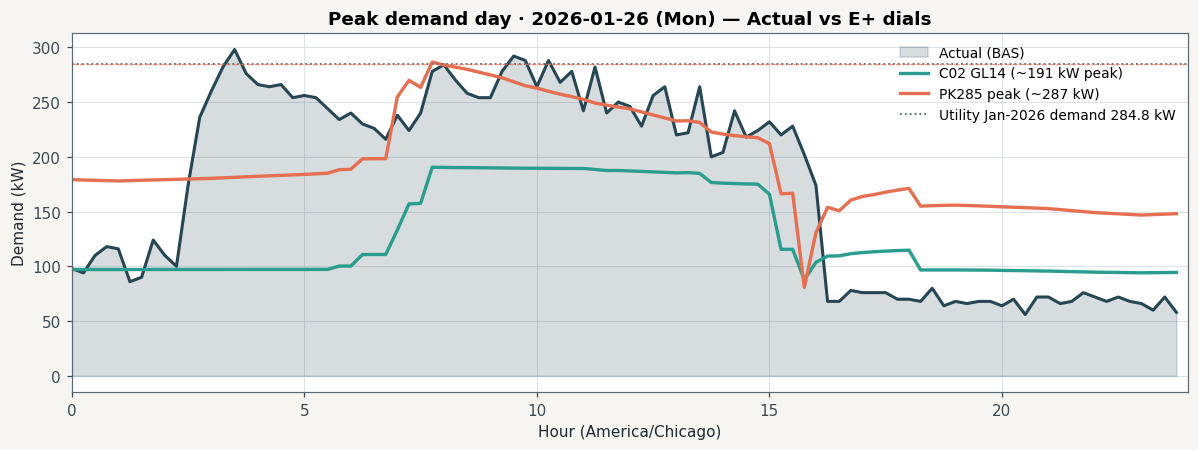

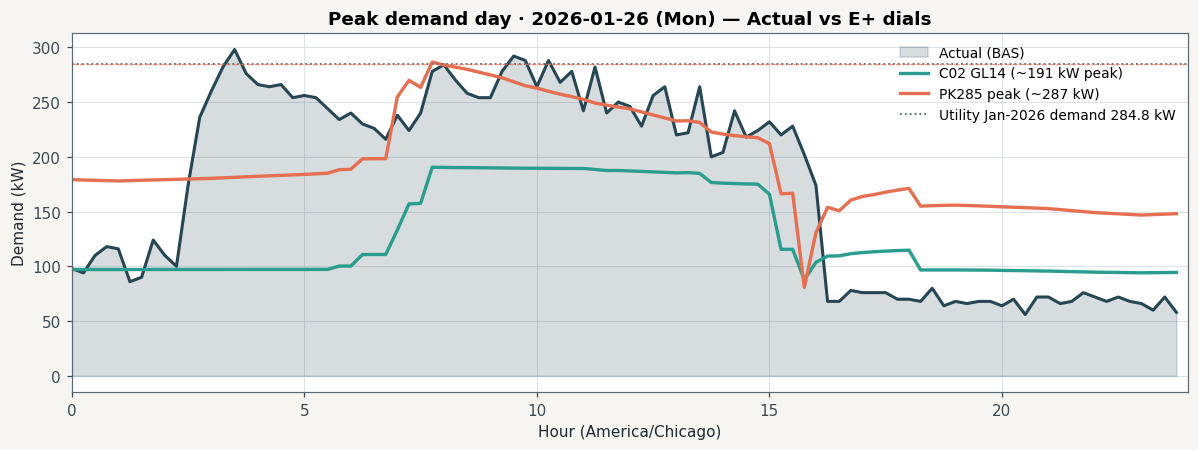

chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\eplus_gl14_vs_peak285\peak_day_actual_c02_pk285.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.fill_between(d_c02["hod"], d_c02["observed_kw"], color=C["actual"], alpha=0.18, label="Actual (BAS)")
ax.plot(d_c02["hod"], d_c02["observed_kw"], color=C["actual"], lw=2.0, label="_nolegend_")
ax.plot(d_c02["hod"], d_c02["simulated_kw"], color=C["c02"], lw=2.0, label="C02 GL14 (~191 kW)")
ax.plot(d_pk["hod"], d_pk["simulated_kw"], color=C["pk285"], lw=2.0, label="PK285 (~287 kW)")
ax.plot(d_l22["hod"], d_l22["simulated_kw"], color=C["l22"], lw=2.0, label="L22 prior (~261 kW)")
ax.plot(d_e20["hod"], d_e20["simulated_kw"], color=C["e20"], lw=2.4, label="E20 enhanced (~271 kW)")
ax.axhline(284.82, color=C["gate"], ls=":", lw=1.2, label="Utility Jan-2026 demand 284.8 kW")
ax.set_xlim(0, 24)
ax.set_xlabel("Hour (America/Chicago)")
ax.set_ylabel("Demand (kW)")
ax.set_title(f"Peak demand day · {day} (Mon) — Actual vs C02 / PK285 / L22 / E20")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
p = save_fig(FIG / "peak_day_actual_c02_pk285_l22_e20.png", fig)
plt.show()
print("chart:", p)

## Winter weekday morning shape (Dec–Feb)

Mean weekday profile — where C02 stays flat/low and PK285 lifts toward measured morning peaks.

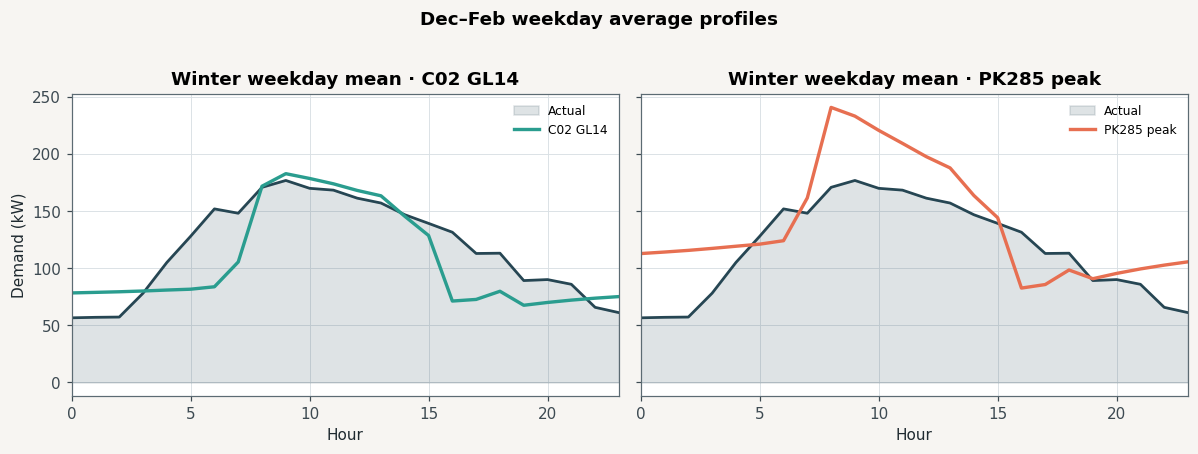

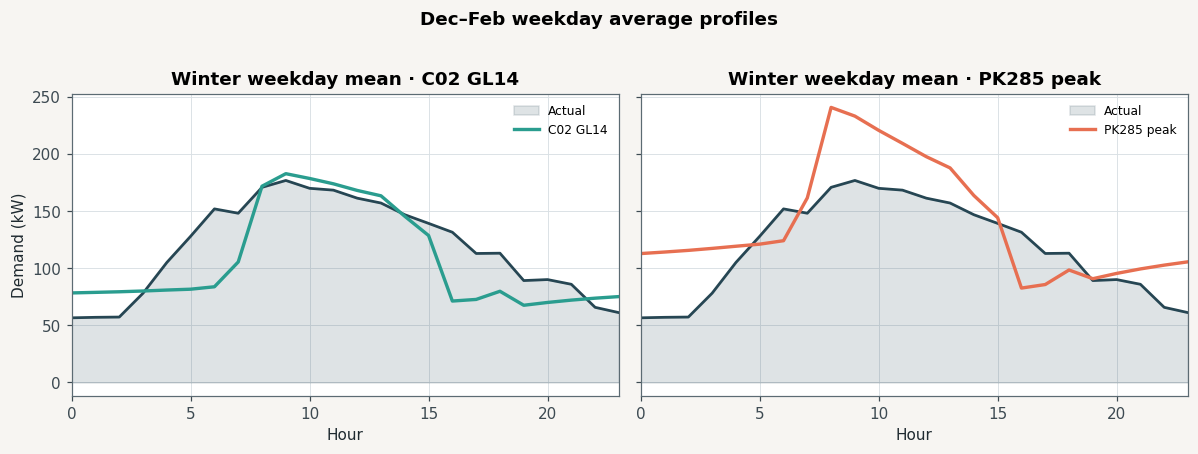

chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\eplus_gl14_vs_peak285\winter_weekday_profiles_c02_pk285.png


In [4]:
def weekday_winter_profile(hourly: pd.DataFrame) -> pd.DataFrame:
    m = hourly["local"].dt.month.isin([12, 1, 2])
    wd = hourly["dow"].between(0, 4)
    g = hourly.loc[m & wd].groupby("hour")
    return pd.DataFrame({
        "obs": g["observed_kw"].mean(),
        "sim": g["simulated_kw"].mean(),
    })

p_c02 = weekday_winter_profile(c02["hourly"])
p_pk = weekday_winter_profile(pk["hourly"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
for ax, prof, lab, col in [
    (axes[0], p_c02, "C02 GL14", C["c02"]),
    (axes[1], p_pk, "PK285 peak", C["pk285"]),
]:
    ax.fill_between(prof.index, prof["obs"], color=C["actual"], alpha=0.15, label="Actual")
    ax.plot(prof.index, prof["obs"], color=C["actual"], lw=1.8)
    ax.plot(prof.index, prof["sim"], color=col, lw=2.2, label=lab)
    ax.set_title(f"Winter weekday mean · {lab}")
    ax.set_xlabel("Hour")
    ax.set_xlim(0, 23)
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("Demand (kW)")
fig.suptitle("Dec–Feb weekday average profiles", y=1.02, fontsize=12, fontweight="semibold")
fig.tight_layout()
p = save_fig(FIG / "winter_weekday_profiles_c02_pk285.png", fig)
plt.show()
print("chart:", p)

## Monthly GL14 — utility bill kWh by month

Observed = billing months. Gates: **|NMBE| < 5%**, **CVRMSE < 15%** (partial-period screen, not purchased G14-2023).

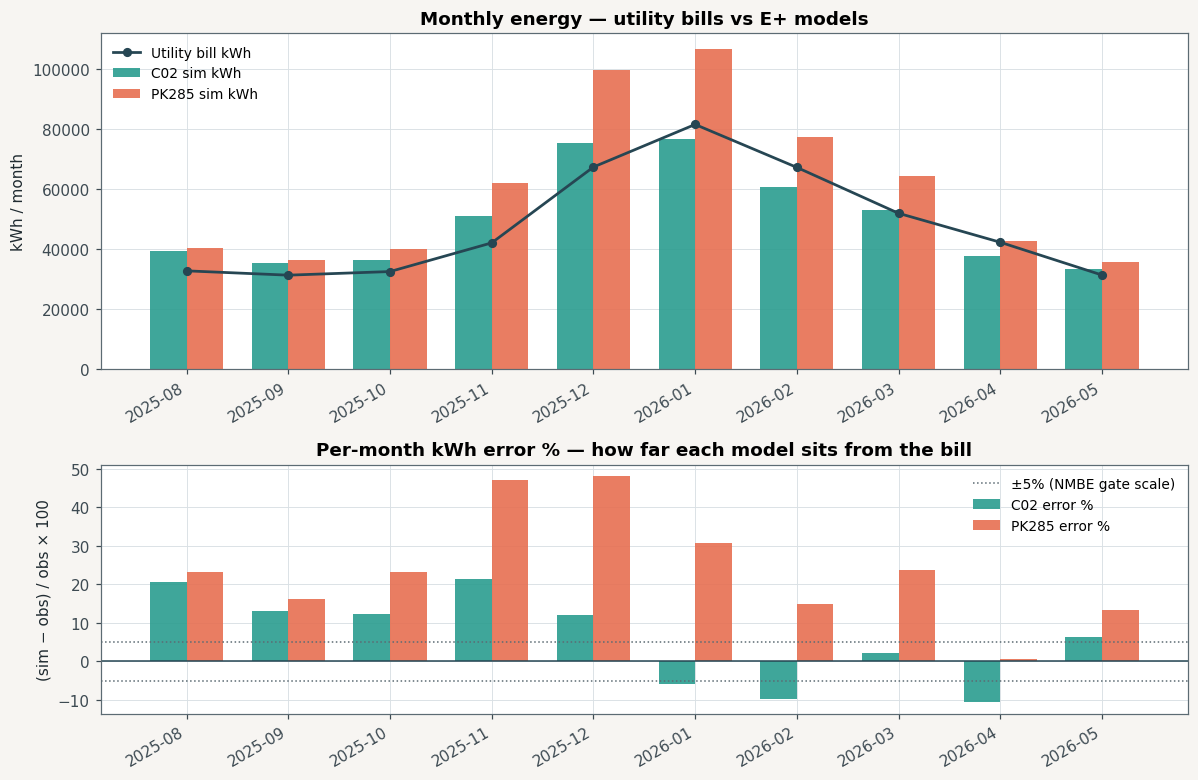

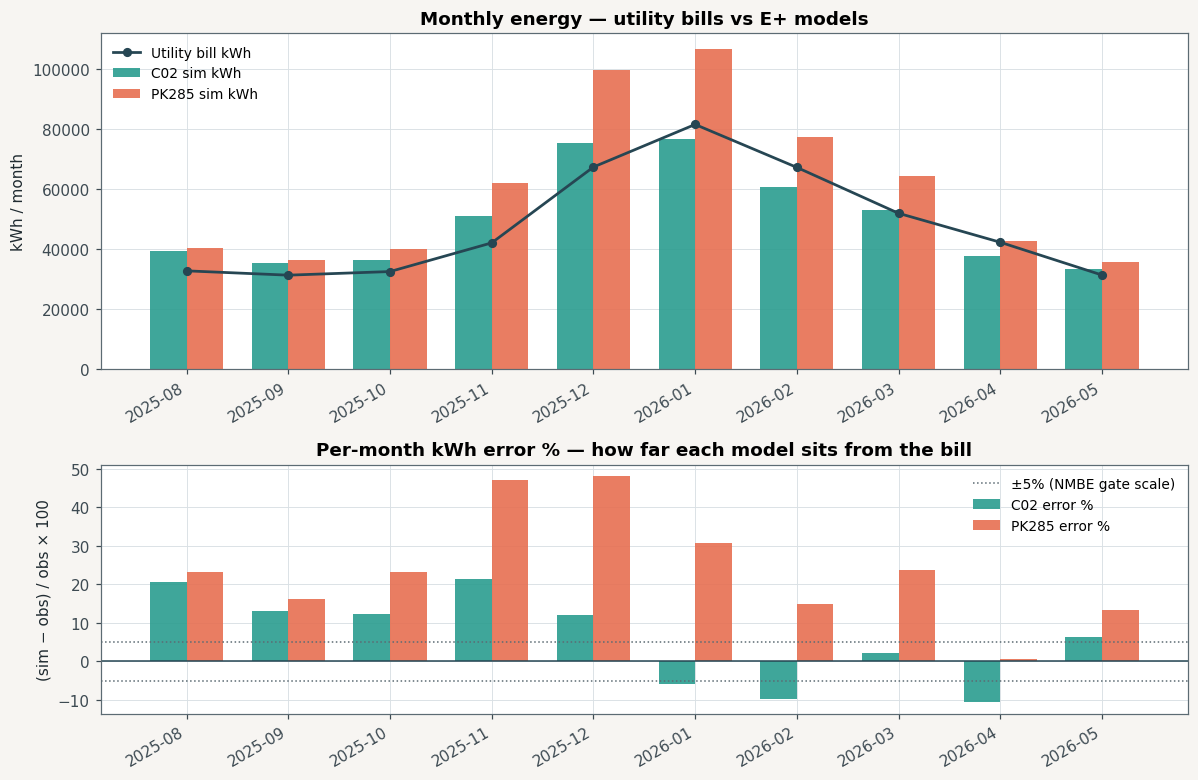

chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\eplus_gl14_vs_peak285\monthly_gl14_kwh_c02_pk285.png


### Gate summary

,model,nmbe_pct,cvrmse_pct,gl14_pass,jan26_peak_kw
0,C02 GL14,-4.43,12.36,True,190.50
1,PK285 peak,-28.71,34.52,False,286.56


In [5]:
both = pd.concat([c02["pairs"], pk["pairs"]], ignore_index=True)
months = sorted(both["month"].unique())
x = np.arange(len(months))
w = 0.36

c02_m = c02["pairs"].set_index("month").reindex(months)
pk_m = pk["pairs"].set_index("month").reindex(months)
obs = c02_m["kwh_obs"]  # same utility obs for both

fig, axes = plt.subplots(2, 1, figsize=(11, 7.2), gridspec_kw={"height_ratios": [1.35, 1]})

ax = axes[0]
ax.bar(x - w / 2, c02_m["kwh_sim"], width=w, color=C["c02"], label="C02 sim kWh", alpha=0.9)
ax.bar(x + w / 2, pk_m["kwh_sim"], width=w, color=C["pk285"], label="PK285 sim kWh", alpha=0.9)
ax.plot(x, obs, color=C["actual"], marker="o", lw=1.8, ms=5, label="Utility bill kWh")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=30, ha="right")
ax.set_ylabel("kWh / month")
ax.set_title("Monthly energy — utility bills vs E+ models")
ax.legend(loc="upper left", fontsize=9)

ax = axes[1]
ax.bar(x - w / 2, c02_m["err_pct"], width=w, color=C["c02"], label="C02 error %", alpha=0.9)
ax.bar(x + w / 2, pk_m["err_pct"], width=w, color=C["pk285"], label="PK285 error %", alpha=0.9)
ax.axhline(0, color=C["actual"], lw=1.0)
ax.axhline(5, color=C["gate"], ls=":", lw=1.0, label="±5% (NMBE gate scale)")
ax.axhline(-5, color=C["gate"], ls=":", lw=1.0)
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=30, ha="right")
ax.set_ylabel("(sim − obs) / obs × 100")
ax.set_title("Per-month kWh error % — how far each model sits from the bill")
ax.legend(loc="upper right", fontsize=9)

fig.tight_layout()
p = save_fig(FIG / "monthly_gl14_kwh_c02_pk285.png", fig)
plt.show()
print("chart:", p)

summary = pd.DataFrame([
    {
        "model": "C02 GL14",
        "nmbe_pct": c02["util"]["nmbe_pct"],
        "cvrmse_pct": c02["util"]["cvrmse_pct"],
        "gl14_pass": c02["hold"]["pass"],
        "jan26_peak_kw": float(d_c02["simulated_kw"].max()),
    },
    {
        "model": "PK285 peak",
        "nmbe_pct": pk["util"]["nmbe_pct"],
        "cvrmse_pct": pk["util"]["cvrmse_pct"],
        "gl14_pass": pk["hold"]["pass"],
        "jan26_peak_kw": float(d_pk["simulated_kw"].max()),
    },
])
display(Markdown("### Gate summary"))
display(summary.round(2))

## Per-month table — both models

Utility `kwh_obs` shared; sim and error % for C02 vs PK285.

In [6]:
tbl = (
    c02_m[["kwh_obs", "kwh_sim", "err_pct"]]
    .rename(columns={"kwh_sim": "c02_kwh_sim", "err_pct": "c02_err_pct"})
    .join(
        pk_m[["kwh_sim", "err_pct"]].rename(
            columns={"kwh_sim": "pk285_kwh_sim", "err_pct": "pk285_err_pct"}
        )
    )
)
tbl["c02_err_pct"] = tbl["c02_err_pct"].round(1)
tbl["pk285_err_pct"] = tbl["pk285_err_pct"].round(1)
tbl["c02_kwh_sim"] = tbl["c02_kwh_sim"].round(0)
tbl["pk285_kwh_sim"] = tbl["pk285_kwh_sim"].round(0)
tbl["kwh_obs"] = tbl["kwh_obs"].round(0)
display(tbl)
out_csv = FIG / "monthly_gl14_both_models.csv"
tbl.to_csv(out_csv)
print("wrote", out_csv)

,kwh_obs,c02_kwh_sim,c02_err_pct,pk285_kwh_sim,pk285_err_pct
month,,,,,
2025-08,32789.0,39530.0,20.6,40377.0,23.1
2025-09,31350.0,35477.0,13.2,36438.0,16.2
2025-10,32552.0,36512.0,12.2,40079.0,23.1
2025-11,42097.0,51130.0,21.5,61866.0,47.0
2025-12,67328.0,75422.0,12.0,99738.0,48.1
2026-01,81491.0,76635.0,-6.0,106533.0,30.7
2026-02,67205.0,60628.0,-9.8,77180.0,14.8
2026-03,51938.0,53084.0,2.2,64201.0,23.6
2026-04,42296.0,37804.0,-10.6,42590.0,0.7


wrote C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\eplus_gl14_vs_peak285\monthly_gl14_both_models.csv


## Tradeoff snapshot — monthly vs peak (agent Pareto)

One chart agents should re-plot after every campaign: with these live knobs you usually hold monthly GL14 **or** hit ~285 kW peak — **E20** is the best dual so far (still short of 285). Pull knobs only in the areas listed in the playbook above.

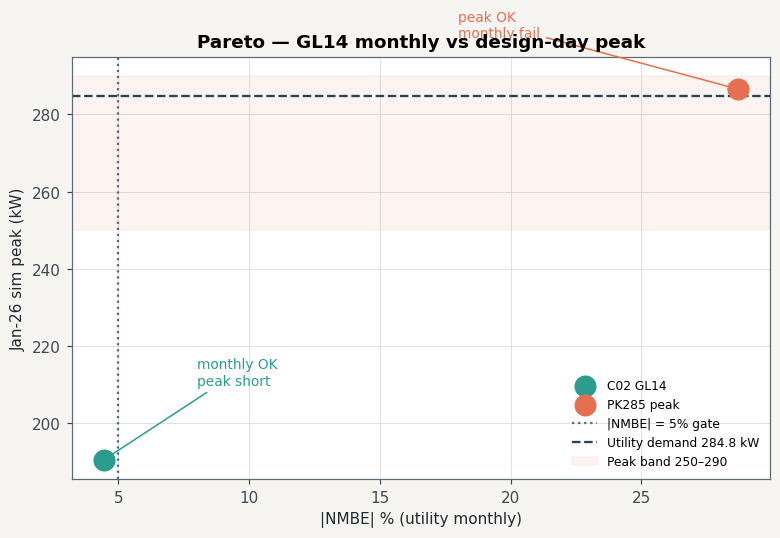

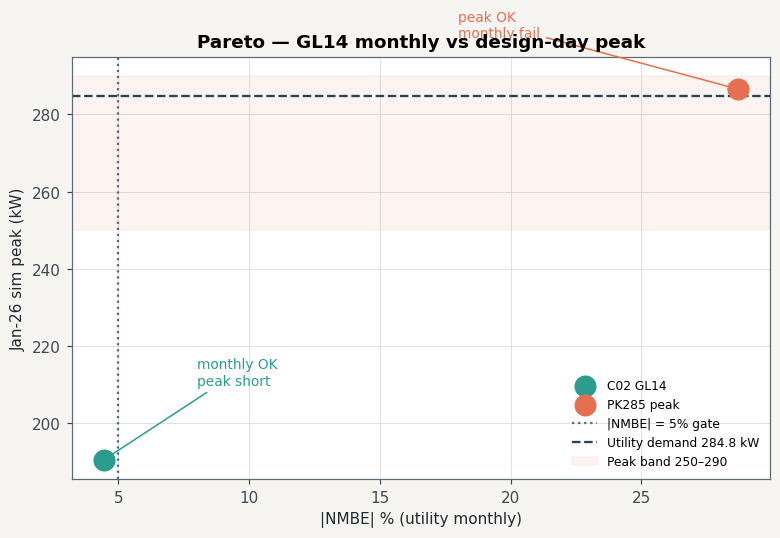

chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\eplus_gl14_vs_peak285\pareto_gl14_vs_peak.png


**Verdict:** C02 passes monthly GL14 (NMBE -4.4%, CV 12.4%) but peaks ~191 kW. PK285 hits ~287 kW but misses GL14 (NMBE -28.7%, CV 34.5% — ~24 / ~20 pts over gates).

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.scatter(
    [abs(c02["util"]["nmbe_pct"])], [d_c02["simulated_kw"].max()],
    s=180, c=C["c02"], zorder=3, label="C02 GL14",
)
ax.scatter(
    [abs(pk["util"]["nmbe_pct"])], [d_pk["simulated_kw"].max()],
    s=180, c=C["pk285"], zorder=3, label="PK285 peak",
)
ax.scatter(
    [abs(l22["util"]["nmbe_pct"])], [d_l22["simulated_kw"].max()],
    s=180, c=C["l22"], zorder=3, label="L22 prior",
)
ax.scatter(
    [abs(e20["util"]["nmbe_pct"])], [d_e20["simulated_kw"].max()],
    s=220, c=C["e20"], zorder=4, label="E20 enhanced",
)
ax.axvline(5.0, color=C["gate"], ls=":", label="|NMBE| = 5% gate")
ax.axhline(284.82, color=C["actual"], ls="--", label="Utility demand 284.8 kW")
ax.axhspan(250, 290, color=C["pk285"], alpha=0.08, label="Peak band 250–290")
ax.annotate("monthly OK\npeak short", xy=(abs(c02["util"]["nmbe_pct"]), d_c02["simulated_kw"].max()),
            xytext=(8, 210), fontsize=9, color=C["c02"],
            arrowprops=dict(arrowstyle="->", color=C["c02"]))
ax.annotate("peak OK\nmonthly fail", xy=(abs(pk["util"]["nmbe_pct"]), d_pk["simulated_kw"].max()),
            xytext=(18, 300), fontsize=9, color=C["pk285"],
            arrowprops=dict(arrowstyle="->", color=C["pk285"]))
ax.annotate("best dual", xy=(abs(e20["util"]["nmbe_pct"]), d_e20["simulated_kw"].max()),
            xytext=(10, 255), fontsize=9, color=C["e20"],
            arrowprops=dict(arrowstyle="->", color=C["e20"]))
ax.set_xlabel("|NMBE| % (utility monthly)")
ax.set_ylabel("Jan-26 sim peak (kW)")
ax.set_title("Pareto — GL14 monthly vs design-day peak")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
p = save_fig(FIG / "pareto_gl14_vs_peak.png", fig)
plt.show()
print("chart:", p)

display(Markdown(
    f"**Verdict:** E20 is the enhanced dual champion — GL14 pass "
    f"(NMBE {e20['util']['nmbe_pct']:+.1f}%, CV {e20['util']['cvrmse_pct']:.1f}%) "
    f"at ~{d_e20['simulated_kw'].max():.0f} kW (+~10 kW vs L22). "
    f"Still ~{285 - d_e20['simulated_kw'].max():.0f} kW short of utility 285. "
    f"Cranking plugs/lights alone hit ~283–294 kW but broke monthly GL14; "
    f"cutting equip×0.75 recovered the bill while keeping opt-start."
))

## End-use tutorial — lights / plugs / HVAC vs actual

Agents: when you turn `equip_w_area_mult` / `lights_w_area_mult`, **re-run this cell** so the stacks match the champion.

EnergyPlus meters here only give **monthly** InteriorLights / InteriorEquipment. We rebuild **hourly** light & plug shapes from school-style schedule fractions, scale them to those monthly totals, and treat the residual (`Facility − lights − plugs`) as estimated HVAC — then overlay **actual** BAS demand (peak day + winter weekday average).

**HP fan run-hours** from `reports/zone_avg_fan_run_hours_monthly.csv` are a qualitative runtime check when cutting plugs after a ~285 kW / GL14-fail trial (not a live W2A knob).

```powershell
python -u scripts/eplus_l22_enduse_profile_plots.py
```

In [ ]:
import subprocess

plot_script = ROOT / "scripts" / "eplus_l22_enduse_profile_plots.py"
print("running", plot_script)
subprocess.run(
    [sys.executable, "-u", str(plot_script)],
    cwd=str(ROOT),
    env={**os.environ, "LAKESIDE_SITE_ROOT": str(SITE), "PYTHONPATH": f"{ROOT};{ROOT/'ml'};{ROOT/'scripts'}"},
    check=False,
)

stats_p = FIG / "enduse_profile_stats.json"
if stats_p.is_file():
    stats = json.loads(stats_p.read_text(encoding="utf-8"))
    display(Markdown(
        f"**Model:** `{stats.get('model')}`  \n"
        f"Winter overnight 0–4 obs mean **{stats.get('winter_overnight_0_4_obs_mean_kw'):.1f} kW** "
        f"(p50 {stats.get('winter_overnight_0_4_obs_p50_kw'):.1f}, p90 {stats.get('winter_overnight_0_4_obs_p90_kw'):.1f})  \n"
        f"Sim overnight mean **{stats.get('winter_overnight_0_4_sim_mean_kw'):.1f} kW**  \n"
        f"Peak-day sim max **{stats.get('peak_day_sim_max_kw'):.1f} kW** vs obs **{stats.get('peak_day_obs_max_kw'):.1f} kW**"
    ))
    hp = (stats.get("hp_fan_runtime") or {})
    if hp.get("jan_building_avg_fan_run_hours") is not None:
        display(Markdown(
            f"Jan zone-avg HP fan run-hours (building mean across zones): "
            f"**{hp['jan_building_avg_fan_run_hours']:.1f} h/HP** — {hp.get('note','')}"
        ))
    for name in (
        f"peak_day_enduse_stack_{stats.get('model')}.png",
        f"winter_wd_avg_enduse_{stats.get('model')}.png",
    ):
        p = FIG / name
        if p.is_file():
            display(Markdown(f"![{name}]({p.as_posix()})"))
            display(HTML(f'<img src="{p.as_uri()}" style="max-width:100%;border:0"/>'))
else:
    print("No enduse_profile_stats.json yet — run the plot script after sims exist.")

# Enhanced dial leaderboard if present
enh = sorted((SITE / "eplus" / "campaigns").glob("w2a_l22_enhanced_*"))
if enh:
    sp = enh[-1] / "summary.json"
    if sp.is_file():
        s = json.loads(sp.read_text(encoding="utf-8"))
        display(Markdown(
            f"### Enhanced L22 campaign `{s.get('campaign_id')}`\n"
            f"- trials: {s.get('n_trials')} · GL14 passers: {s.get('gl14_passers')}\n"
            f"- dual candidates: {s.get('dual_candidates')}\n"
            f"- improved vs L22: **{s.get('improved_vs_l22')}** → champion **`{s.get('champion_recommendation')}`**"
        ))
        display(pd.DataFrame(s.get("trials") or []))
else:
    print("No w2a_l22_enhanced_* campaign yet.")